# fullabovemeannn: true vs predicted magnitude

## Context & Methods
An overlapping histogram for `best_model_fullabovemeannn.pth` on the same 82,769 test traces used in the five-model evaluation. Both distributions use identical 30-bin edges. Predictions are read from the completed evaluation and already use the validation-selected waveform cache and output decoding; **do not add the target mean again**.

The saved outputs below are executed. Rerunning this notebook redraws the chart from saved predictions and does not rerun model inference.

## Data

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

MODEL_NAME = 'best_model_fullabovemeannn'
BASE = Path.cwd()
if not (BASE / 'evaluation_artifacts').exists():
    BASE = BASE / 'explore'
ART = BASE / 'evaluation_artifacts'

with np.load(ART / 'test_decoded.npz') as data:
    results = pd.DataFrame({
        'true_magnitude': data['y'],
        'predicted_magnitude': data[MODEL_NAME]
    })

assert len(results) == 82769
assert np.isfinite(results.to_numpy()).all()
configuration = pd.read_csv(ART / 'selected_configurations.csv')
display(configuration.loc[configuration['model'] == MODEL_NAME,
                          ['model', 'cache', 'decoding', 'offset']])
display(results.agg(['count', 'mean', 'std', 'min', 'max']))

,model,cache,decoding,offset
3,best_model_fullabovemeannn,fullnn,add_train_mean,2.288021


,true_magnitude,predicted_magnitude
count,82769.000000,82769.000000
mean,2.217452,2.237272
std,0.714146,0.468256
min,0.100000,0.631170
max,4.500000,5.850010


## Results
### True vs predicted — all test traces

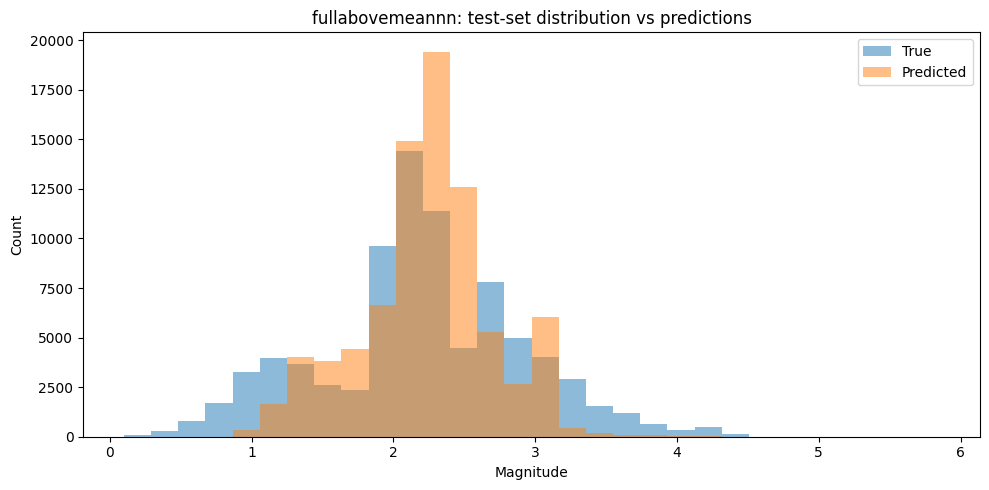

In [2]:
# Shared edges make the two distributions directly comparable.
bins = np.histogram_bin_edges(results.to_numpy().ravel(), bins=30)

plt.figure(figsize=(10, 5))
plt.hist(results['true_magnitude'], bins=bins, alpha=0.5, label='True')
plt.hist(results['predicted_magnitude'], bins=bins, alpha=0.5, label='Predicted')
plt.title(f"{MODEL_NAME.replace('best_model_', '')}: test-set distribution vs predictions")
plt.xlabel('Magnitude')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

## Takeaways

In [3]:
bias = (results['predicted_magnitude'] - results['true_magnitude']).mean()
print(f'Mean prediction − true magnitude: {bias:+.4f}')
print('Histogram overlap describes the distributions, not whether individual predictions are correct.')

Mean prediction − true magnitude: +0.0198
Histogram overlap describes the distributions, not whether individual predictions are correct.
